In [32]:
23.1
from geopy.distance import distance
import folium
UEH = (10.773186808599574, 106.67766776908353)
m = folium.Map(location=UEH, zoom_start=15)
locations = [
    ("bệnh viện", 10.774174363901645, 106.66606557802692),
    ("trung tâm thương mại", 10.770631772401348, 106.66986330405778),
    (" bến xe", 10.740987765889846, 106.6192821746157),
    (" cơ quan hành chính", 10.761736352099641, 106.68574218073454)
]
for name, lat, lon in locations:
    folium.Marker(
        location=[lat, lon],
        popup=name
    ).add_to(m)

m

In [33]:
23.2
from geopy.distance import distance
import folium
UEH_coord = (10.773186808599574, 106.67766776908353)
locations = [
    ("Bệnh viện 115", 10.774174363901645, 106.66606557802692),
    ("Vạn Hạnh Mall", 10.770631772401348, 106.66986330405778),
    ("Bến xe Miền Tây", 10.740987765889846, 106.6192821746157),
    ("Ủy ban Nhân dân", 10.761736352099641, 106.68574218073454)
]
m = folium.Map(location=UEH_coord, zoom_start=15)
folium.Marker(
    location=UEH_coord,
    popup="Tâm điểm: Đại học UEH",
    icon=folium.Icon(color='red', icon='star')
).add_to(m)
for name, lat, lon in locations:
    dest_coord = (lat, lon)
    dist = distance(UEH_coord, dest_coord).km
    folium.Marker(
        location=[lat, lon],
        popup=f"<b>{name}</b><br>Cách UEH: {dist:.2f} km",
        tooltip=name
    ).add_to(m)
    folium.PolyLine(
        locations=[UEH_coord, dest_coord],
        color='blue',
        weight=2,
        opacity=0.6,
        dash_array='5, 5'
    ).add_to(m)
m

In [35]:
23.3
import folium
from folium.plugins import HeatMap
map_hcm =  folium.Map(location=[10.836267412613253, 106.64311321002798], zoom_start=15)
data = [
    [10.807620828643886, 106.6321583653019],
    [10.761146564529533, 106.66837527183394],
    [10.761167650142209, 106.6688367275999],
    [10.760724851966346, 106.66892257983542],
    [10.760908127361452, 106.6684798464915],
    [10.760841050136442, 106.66823897727876],
    [10.761319338711267, 106.66839849841473],
    [10.761245546700536, 106.66847361138176],
    [10.760909499730227, 106.66796257019055],
    [10.76081354202822, 106.66820343939764],
    [10.760606720469548, 106.66808205648172],
    [10.760569455308287, 106.66791420667629],
]
HeatMap(data).add_to(map_hcm)
map_hcm

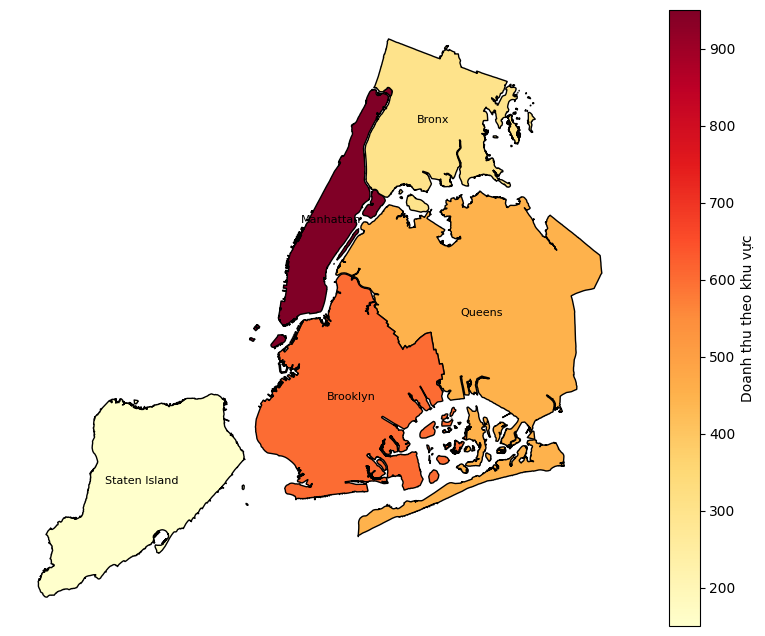

In [98]:
23.4
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from geodatasets import get_path
path = get_path("nybb")
gdf = gpd.read_file(path)
data = {
    'BoroName': ['Staten Island', 'Queens', 'Brooklyn', 'Manhattan', 'Bronx'],
    'Revenue': [150, 450, 600, 950, 300],
    'Orders': [1200, 3500, 5000, 8000, 2500]
}
df_stats = pd.DataFrame(data)
merged_gdf = gdf.merge(df_stats, on="BoroName")
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
merged_gdf.plot(column='Revenue',
                cmap='YlOrRd',
                legend=True,
                legend_kwds={'label': "Doanh thu theo khu vực"},
                edgecolor='black',
                ax=ax)
for x, y, label in zip(merged_gdf.geometry.centroid.x, merged_gdf.geometry.centroid.y, merged_gdf['BoroName']):
    ax.text(x, y, label, fontsize=8, ha='center')
plt.axis('off')
plt.show()

In [38]:
23.5
from textwrap import fill
import folium
UEH = [10.76105908240866, 106.66836154477902]
m = folium.Map(location=UEH, zoom_start=15)
folium.Marker(
    UEH, # Use UEH variable here instead of 'location'
    icon=folium.Icon(color='red', icon='star')
).add_to(m)
folium.Circle(
    UEH, # Use UEH variable here instead of 'location'
    radius=10000,
    color='blue',
    fill=True,
    fill_color='blue',
    fill_opacity=0.2
).add_to(m)
m

--- PHÂN TÍCH MẠNG LƯỚI GIAO THÔNG QUANH lotte ---
Số lượng nút giao (Intersections): 1181
Số lượng đoạn đường (Edges): 2622
Chiều dài trung bình mỗi đoạn đường: 54.03 mét
Tổng chiều dài mạng lưới: 75.96 km


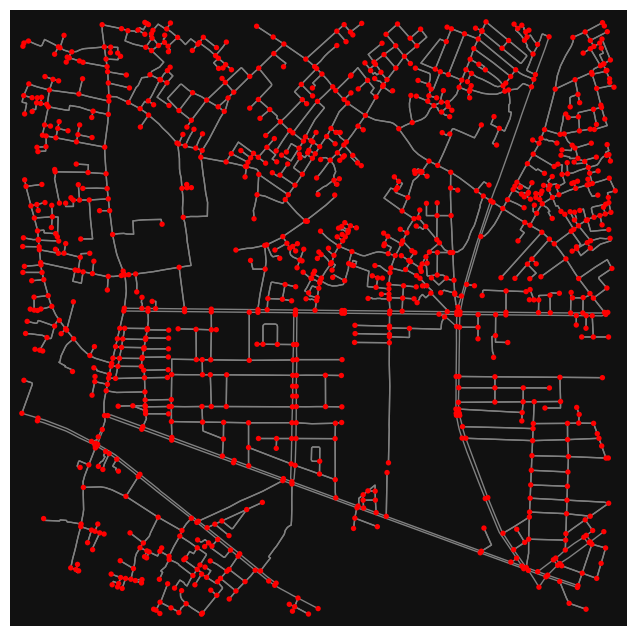

In [39]:
23.6
!pip install osmnx
import matplotlib.pyplot as plt
lotte_coords = (10.83845470088192, 106.67124636296528)
dist = 1000
G = ox.graph_from_point(lotte_coords, dist=dist, network_type='drive')
stats = ox.basic_stats(G)
print("--- PHÂN TÍCH MẠNG LƯỚI GIAO THÔNG QUANH lotte ---")
print(f"Số lượng nút giao (Intersections): {stats['n']}")
print(f"Số lượng đoạn đường (Edges): {stats['m']}")
print(f"Chiều dài trung bình mỗi đoạn đường: {stats['street_length_avg']:.2f} mét")
print(f"Tổng chiều dài mạng lưới: {stats['street_length_total'] / 1000:.2f} km")
fig, ax = ox.plot_graph(G, node_color='red', node_size=15, edge_color='gray', edge_linewidth=1)
plt.show()

In [73]:
23.7
!pip install osmnx networkx folium
import osmnx as ox
import networkx as nx
import folium

place = "Ho Chi Minh City, Vietnam"
G = ox.graph_from_point((10.7769, 106.7009), dist=2000, network_type='drive')
start = (10.838444163434728, 106.67084939607474)
end = (10.838876198463135, 106.66858561187041)
orig = ox.distance.nearest_nodes(G, start[1], start[0])
dest = ox.distance.nearest_nodes(G, end[1], end[0])
route_dijkstra = nx.shortest_path(G, orig, dest, weight='length')
route_astar = nx.astar_path(
    G, orig, dest,
    heuristic=lambda u, v: 0,
    weight='length'
)
m = folium.Map(location=start, zoom_start=13)
folium.Marker(location=start, popup="Điểm Bắt đầu", icon=folium.Icon(color='green')).add_to(m)
folium.Marker(location=end, popup="Điểm Kết thúc", icon=folium.Icon(color='purple')).add_to(m)
route_dijkstra_coords = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in route_dijkstra]
folium.PolyLine(route_dijkstra_coords, color='red', weight=5, opacity=0.7, popup="Tuyến đường Dijkstra").add_to(m)
route_astar_coords = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in route_astar]
folium.PolyLine(route_astar_coords, color='blue', weight=3, opacity=0.7, popup="Tuyến đường A*").add_to(m)
m

In [74]:
from geopy.distance import distance

distance_km = distance(start, end).km
print(f"Khoảng cách thực tế giữa điểm bắt đầu và điểm kết thúc là: {distance_km:.2f} km")

Khoảng cách thực tế giữa điểm bắt đầu và điểm kết thúc là: 0.25 km


In [44]:
23.8
import folium
from geopy.distance import distance
UEH =(10.783240880209046, 106.69461991631741)
m = folium.Map(location=UEH, zoom_start=15)
costumers = [
    {"id": "khách A", "pos": (10.782940507550652, 106.69424977151407)},
    {"id": "khách B", "pos": (10.782723601686097, 106.69384557596076)},
]
drives = [
    {"id": "Tài xế 1", "pos": (10.782935997413926, 106.69450180231989)},
    {"id": "Tài xế 2", "pos": (10.783038468984346, 106.693940406357)},
    {"id": "Tài xế 3", "pos": (10.783632803404728, 106.69512388974192)},
]
assigned_pairs = []
for customer in costumers:
    closest_driver = None
    min_dist = float('inf')
    for driver in drives:
        d = distance(customer['pos'], driver['pos']).km
        if d < min_dist:
            min_dist = d
            closest_driver = driver
    if closest_driver:
        assigned_pairs.append((customer, closest_driver, min_dist))

for c in costumers:
    folium.Marker(c['pos'], popup=c['id'], icon=folium.Icon(color='red', icon='user', prefix='fa')).add_to(m)
for d in drives:
    folium.Marker(d['pos'], popup=d['id'], icon=folium.Icon(color='blue', icon='car', prefix='fa')).add_to(m)
for c, d, dist in assigned_pairs:
    folium.PolyLine(
        locations=[c['pos'], d['pos']],
        color='green',
        weight=3,
        dash_array='10, 10',
        popup=f"Khoảng cách đón: {dist:.2f} km"
    ).add_to(m)
m

In [82]:
23.9
import folium
import random
from sklearn.cluster import KMeans
data = []
for _ in range(50):
    lat = 10.83653443917025 + random.uniform(-0.07, 0.06)
    lon = 106.6756645107924 + random.uniform(-0.08, 0.07)
    data.append([lat, lon])
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(data)
labels = kmeans.labels_
centers = kmeans.cluster_centers_
m = folium.Map(location=[10.83653443917025, 106.6756645107924], zoom_start=12)

colors = ['red', 'blue', 'green']
for i, point in enumerate(data):
    folium.CircleMarker(
        location=point,
        radius=5,
        color=colors[labels[i]],
        fill=True
    ).add_to(m)
for center in centers:
    folium.Marker(
        location=center,
        icon=folium.Icon(color='black', icon='home'),
        popup='Kho đề xuất'
    ).add_to(m)

m

In [83]:
23.10
import folium
UEH = [10.761042649231326, 106.66831508073467]
m = folium.Map(location=UEH, zoom_start=15)
diem_giao_thong = [
    ["Ngã tư Nguyễn Tri Phương", 10.759000452716306, 106.669096324909, 70],
    [" Cổng trường dân chủ", 10.777958077154743, 106.68140157918369, 90],
    ["Đường Nguyễn Đình Chiểu", 10.779407756566137, 106.69075966908343, 20],
]
for ten, lat, lon, mat_do in diem_giao_thong:
    if mat_do > 80:
        mau_sac = "red"
    elif mat_do > 40:
        mau_sac = "orange"
    else:
        mau_sac = "green"
    folium.Circle(
        location=[lat, lon],
        radius=170,
        color=mau_sac,
        fill=True,
        fill_opacity=0.5,
        popup=f"{ten}: {mat_do}%"
    ).add_to(m)

m

In [84]:
23.11
import folium
UEH = [10.77341868275364, 106.6777321420928]
m = folium.Map(location=UEH, zoom_start=14)
demand_data = [
    ["Khu vực UEH", [10.762372662460644, 106.66880569586654], 95, 40],
    ["Chợ Bến Thành", [10.772727584545493, 106.69812808442295], 80, 50],
    ["Khu Cư xá Bắc Hải", [10.782109396813135, 106.66289189795323], 60, 30],
    ["Bệnh viện 115", [10.7741588877604, 106.66593036900116], 70, 85]
]
gio_xem = "sang"
for name, pos, demand_sang, demand_chieu in demand_data:
    current_demand = demand_sang if gio_xem == "sang" else demand_chieu
    if current_demand > 80:
        mau = "red"    # Nhu cầu cực cao
    elif current_demand > 50:
        mau = "orange" # Nhu cầu trung bình
    else:
        mau = "blue"   # Nhu cầu thấp
    folium.CircleMarker(
        location=pos,
        radius=current_demand / 4,
        color=mau,
        fill=True,
        fill_opacity=0.6,
        popup=f"{name}<br>Nhu cầu: {current_demand} đơn/giờ"
    ).add_to(m)

m